In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/figure3_S4/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [2]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


G:\Miniconda3\envs\omicverse\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset,species
sample,,,,,,,,
9.5gw,gw9,not_provided_1,9,female,SC3,snRNA-seq,public,Homo sapiens
11.2gw,gw11,not_provided_2,11,male,SC3,snRNA-seq,public,Homo sapiens
14+3gw,gw14,F20240701,14,male,SC3,snRNA-seq,in-house,Homo sapiens
15gw,gw15,not_provided_3,15,female,SC3,scRNA-seq,public,Homo sapiens
16+4gw,gw16,F20241018,16,male,SC3,snRNA-seq,in-house,Homo sapiens
17+2gw,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house,Homo sapiens
17+3gw,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house,Homo sapiens
17gw,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public,Homo sapiens
18+3gw,gw18,F20220806,18,male,SC3,snRNA-seq,in-house,Homo sapiens


In [4]:
import scvelo as scv
scv.set_figure_params(figsize=(4,4))
import matplotlib.pyplot as plt

In [84]:
adata_mouse = sc.read("mouse_developmental_hc_python_human_id.h5ad")
print("adata_mouse dims: {}".format(adata_mouse.shape)) 

adata_mouse dims: (2915, 16823)


In [85]:
adata_mouse.layers["counts"] = adata_mouse.X.copy() 
adata_mouse.layers['counts']

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 6250435 stored elements and shape (2915, 16823)>

In [86]:
sc.pp.normalize_total(adata_mouse, target_sum=1e4)
sc.pp.log1p(adata_mouse)

normalizing counts per cell
    finished (0:00:00)


### FIGURE S4a/b

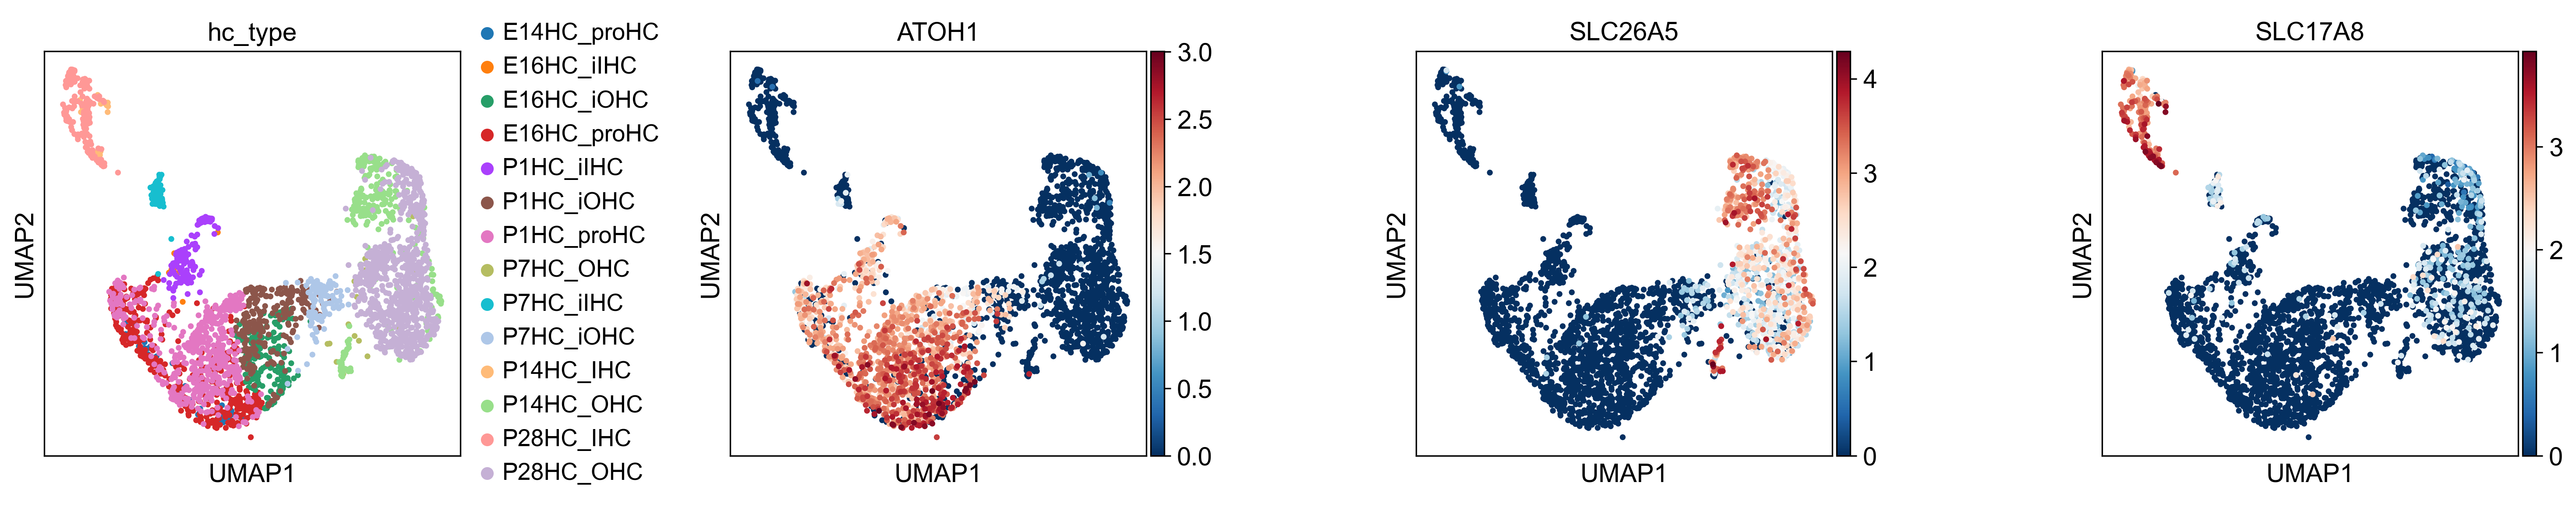

In [8]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(
    adata_mouse,
    color=['hc_type','ATOH1','SLC26A5','SLC17A8',],wspace=0.5,
    frameon=True,
    save="_mouse_developmental_hc.pdf",
)#ncols = 1,

### FIGURE S4c/d

In [9]:
adata_human_hc=sc.read('human_prenatal_hc_final_v2.h5ad')

In [12]:
cut_labels_5 = ['< 12', '< 16','< 20','< 24','< 28', ]
cut_bins = [0, 12, 16,20,24,28 ]

adata_human_hc.obs["age_bins2"] = pd.cut(adata_human_hc.obs["gw"], bins=cut_bins, labels=cut_labels_5).astype("str")
adata_human_hc.obs["age_bins2"] = pd.Categorical(adata_human_hc.obs["age_bins2"], categories=cut_labels_5, ordered=True)
adata_human_hc.obs["age_bins2"]

14+3gw_AACAAAGCATTCTCCG    < 16
14+3gw_AACAACCAGTGCGCTC    < 16
14+3gw_AAGCGTTAGGCACTCC    < 16
14+3gw_ACAGAAAAGGTGCCAA    < 16
14+3gw_ACCATTTAGGCCGCTT    < 16
                           ... 
23+2gw_TAGTGAGAGTGAGGGT    < 24
23+2gw_TCAAGAACACAACAGG    < 24
23+2gw_TGATCAATCCGGTTGA    < 24
23+2gw_TGCTAGCCAATTAGCT    < 24
23+2gw_TGGACTAGTGCTCCAC    < 24
Name: age_bins2, Length: 203, dtype: category
Categories (5, object): ['< 12' < '< 16' < '< 20' < '< 24' < '< 28']

In [13]:
# Convert covariate to continous
adata_human_hc.obs['age_bins2'] = adata_human_hc.obs['age_bins2'].cat.codes
adata_human_hc.obs['age_bins2']
adata_human_hc.obs.groupby(['gw','sample_id','age_bins2']).apply(len)

14+3gw_AACAAAGCATTCTCCG    1
14+3gw_AACAACCAGTGCGCTC    1
14+3gw_AAGCGTTAGGCACTCC    1
14+3gw_ACAGAAAAGGTGCCAA    1
14+3gw_ACCATTTAGGCCGCTT    1
                          ..
23+2gw_TAGTGAGAGTGAGGGT    3
23+2gw_TCAAGAACACAACAGG    3
23+2gw_TGATCAATCCGGTTGA    3
23+2gw_TGCTAGCCAATTAGCT    3
23+2gw_TGGACTAGTGCTCCAC    3
Name: age_bins2, Length: 203, dtype: int8

gw  sample_id  age_bins2
14  gw14       1            89
15  gw15       1            17
16  gw16       1            33
17  gw17_1     2             1
    gw17_3     2            30
18  gw18       2             2
22  gw22_1     3             1
23  gw23       3            30
dtype: int64

In [23]:
adata_human_IHC=adata_human_hc[adata_human_hc.obs['cell_type_final_v4'].isin([ 'Inner_HC', ])]
adata_human_IHC.obs['cell_type_final_v4'].value_counts()

cell_type_final_v4
Inner_HC    109
Name: count, dtype: int64

In [24]:
adata_human_OHC=adata_human_hc[adata_human_hc.obs['cell_type_final_v4'].isin([ 'Outer_HC', ])]
adata_human_OHC.obs['cell_type_final_v4'].value_counts()

cell_type_final_v4
Outer_HC    94
Name: count, dtype: int64

In [25]:
#sc.pp.regress_out(adata_human_IHC, ['total_counts'])
#sc.pp.scale(adata_human_IHC, max_value=10)
sc.pp.normalize_total(adata_human_IHC, target_sum=1e4)
sc.pp.log1p(adata_human_IHC)
sc.pp.normalize_total(adata_human_OHC, target_sum=1e4)
sc.pp.log1p(adata_human_OHC)

In [32]:
genes = ['ATOH1', 'SOX2', 
         'TMC1','TMC2',
          'OTOF','SLC17A8','SLC7A14','FGF8',
         'TBX2', 'CASZ1','INSM1']

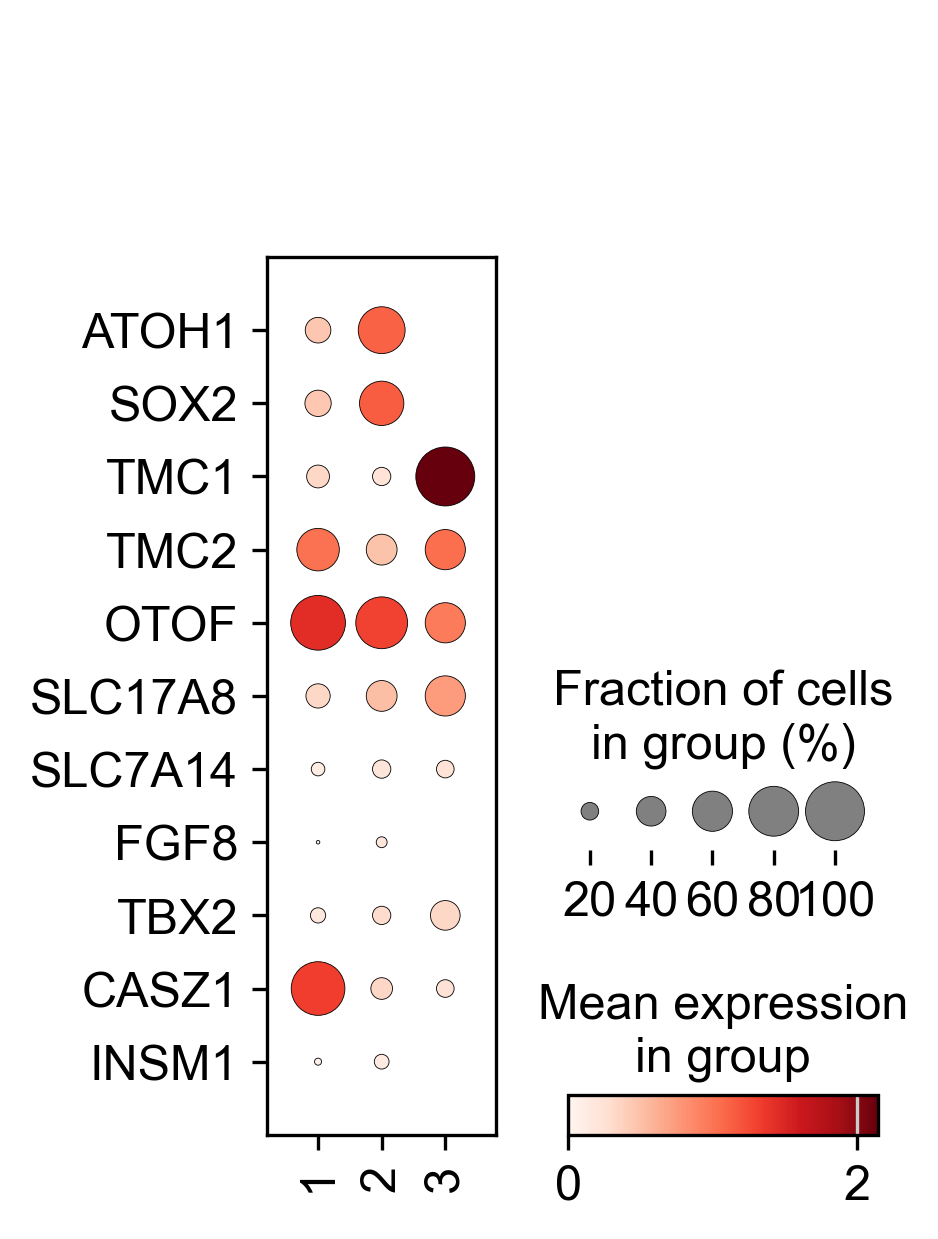

In [35]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
adata_human_IHC.obs['age_bins2'] = adata_human_IHC.obs['age_bins2'].astype(str)
sc.pl.dotplot(adata_human_IHC, var_names=genes, groupby='age_bins2', swap_axes=True,
             save="_human_developmental_inner_hc2.pdf",#standard_scale='var'
             )#standard_scale='var'


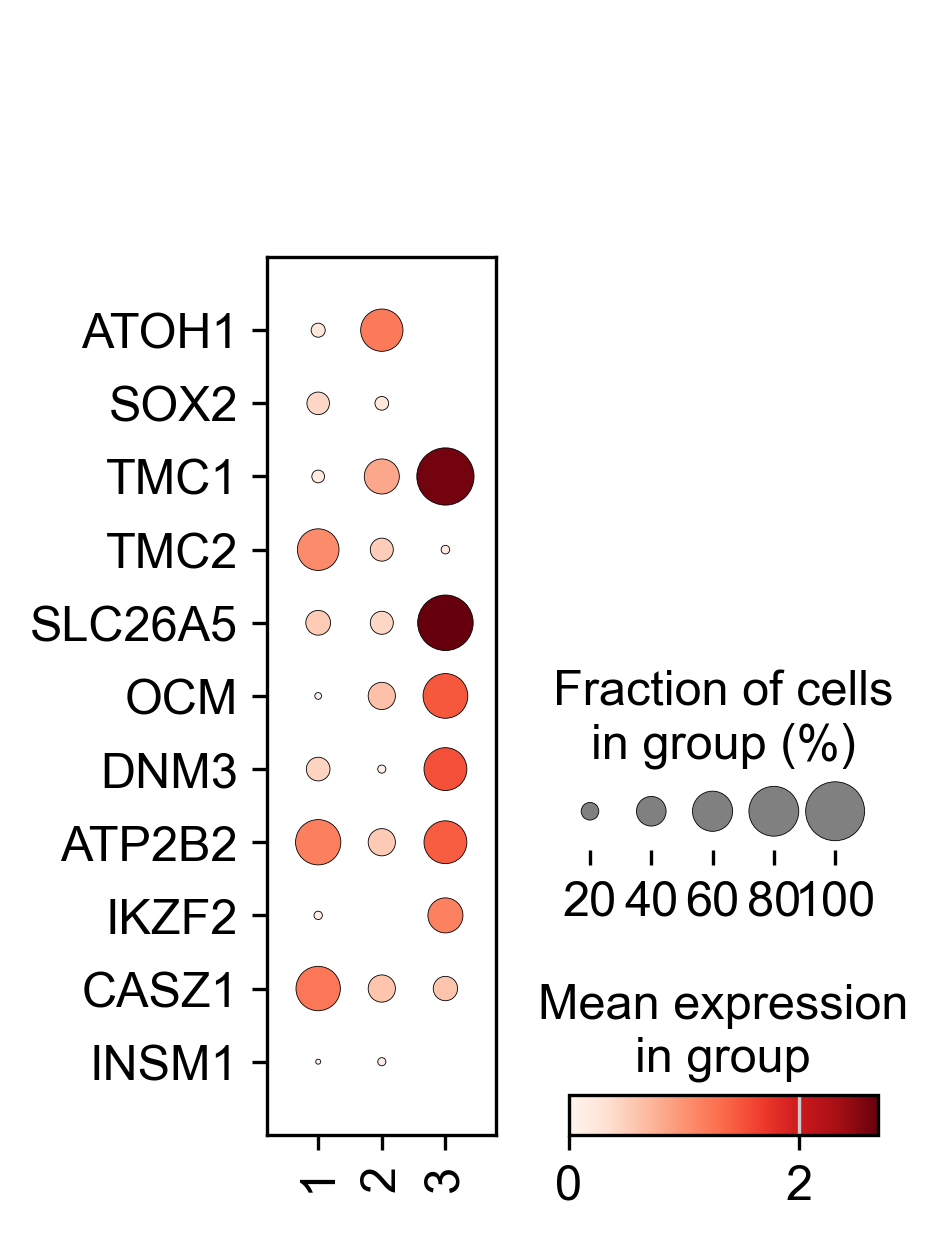

In [36]:
# Convert to categorical and specify the order if necessary
age_bins_order = sorted(adata_human_OHC.obs['age_bins2'].unique())
adata_human_OHC.obs['age_bins2'] = pd.Categorical(adata_human_OHC.obs['age_bins2'], categories=age_bins_order, ordered=True)

# Ensure 'age_bins2' is categorical
adata_human_OHC.obs['age_bins2'] = adata_human_OHC.obs['age_bins2'].astype('category')
genes2 = ['ATOH1', 'SOX2', 
         'TMC1','TMC2',
          'SLC26A5','OCM','DNM3','ATP2B2',
         'IKZF2', 'CASZ1','INSM1']
sc.pl.dotplot(adata_human_OHC, var_names=genes2, groupby='age_bins2',swap_axes=True, 
             save="_human_developmental_outer_hc2.pdf",)#standard_scale='var'

In [37]:
adata_mouse_IHC=adata_mouse[adata_mouse.obs['subtype'].isin([ 'E16iHC','E14iHC','P1IHC','P7IHC','P14IHC','P28IHC' ])]
adata_mouse_IHC.obs['subtype'].value_counts()
adata_mouse_IHC.obs['timepoint'].value_counts()

subtype
E16iHC    583
P1IHC     181
P28IHC    160
P7IHC      61
E14iHC     58
P14IHC     33
Name: count, dtype: int64

timepoint
E16HC    583
P1HC     181
P28HC    160
P7HC      61
E14HC     58
P14HC     33
Name: count, dtype: int64

In [38]:
adata_mouse_IHC_E14=adata_mouse_IHC[adata_mouse_IHC.obs['hc_type'].isin([ 'E14HC_proHC', ])]
adata_mouse_IHC_E14.obs['hc_type'].value_counts()
adata_mouse_IHC_E14.obs['timepoint'].value_counts()
adata_mouse_IHC_E14.obs['devtime']='1'
adata_mouse_IHC_E16=adata_mouse_IHC[adata_mouse_IHC.obs['hc_type'].isin([ 'E16HC_iIHC', ])]
adata_mouse_IHC_E16.obs['hc_type'].value_counts()
adata_mouse_IHC_E16.obs['timepoint'].value_counts()
adata_mouse_IHC_E16.obs['devtime']='1'

hc_type
E14HC_proHC    58
Name: count, dtype: int64

timepoint
E14HC    58
Name: count, dtype: int64

hc_type
E16HC_iIHC    10
Name: count, dtype: int64

timepoint
E16HC    10
Name: count, dtype: int64

In [39]:
adata_mouse_IHC_P1=adata_mouse_IHC[adata_mouse_IHC.obs['hc_type'].isin([ 'P1HC_iIHC', ])]
adata_mouse_IHC_P1.obs['hc_type'].value_counts()
adata_mouse_IHC_P1.obs['timepoint'].value_counts()
adata_mouse_IHC_P1.obs['devtime']='2'
adata_mouse_IHC_P7=adata_mouse_IHC[adata_mouse_IHC.obs['hc_type'].isin([ 'P7HC_iIHC', ])]
adata_mouse_IHC_P7.obs['hc_type'].value_counts()
adata_mouse_IHC_P7.obs['timepoint'].value_counts()
adata_mouse_IHC_P7.obs['devtime']='2'

hc_type
P1HC_iIHC    126
Name: count, dtype: int64

timepoint
P1HC    126
Name: count, dtype: int64

hc_type
P7HC_iIHC    61
Name: count, dtype: int64

timepoint
P7HC    61
Name: count, dtype: int64

In [40]:
adata_mouse_IHC_P14=adata_mouse_IHC[adata_mouse_IHC.obs['hc_type'].isin([ 'P14HC_IHC', ])]
adata_mouse_IHC_P14.obs['hc_type'].value_counts()
adata_mouse_IHC_P14.obs['timepoint'].value_counts()
adata_mouse_IHC_P14.obs['devtime']='3'
adata_mouse_IHC_P28=adata_mouse_IHC[adata_mouse_IHC.obs['hc_type'].isin([ 'P28HC_IHC', ])]
adata_mouse_IHC_P28.obs['hc_type'].value_counts()
adata_mouse_IHC_P28.obs['timepoint'].value_counts()
adata_mouse_IHC_P28.obs['devtime']='3'

hc_type
P14HC_IHC    33
Name: count, dtype: int64

timepoint
P14HC    33
Name: count, dtype: int64

hc_type
P28HC_IHC    160
Name: count, dtype: int64

timepoint
P28HC    160
Name: count, dtype: int64

In [41]:
adata_mouse_IHC=adata_mouse_IHC_P28.concatenate(adata_mouse_IHC_P14,adata_mouse_IHC_P7,adata_mouse_IHC_P1,adata_mouse_IHC_E16,
                                                adata_mouse_IHC_E14
                                               )

In [42]:
sc.pp.normalize_total(adata_mouse_IHC, target_sum=1e4)
sc.pp.log1p(adata_mouse_IHC)

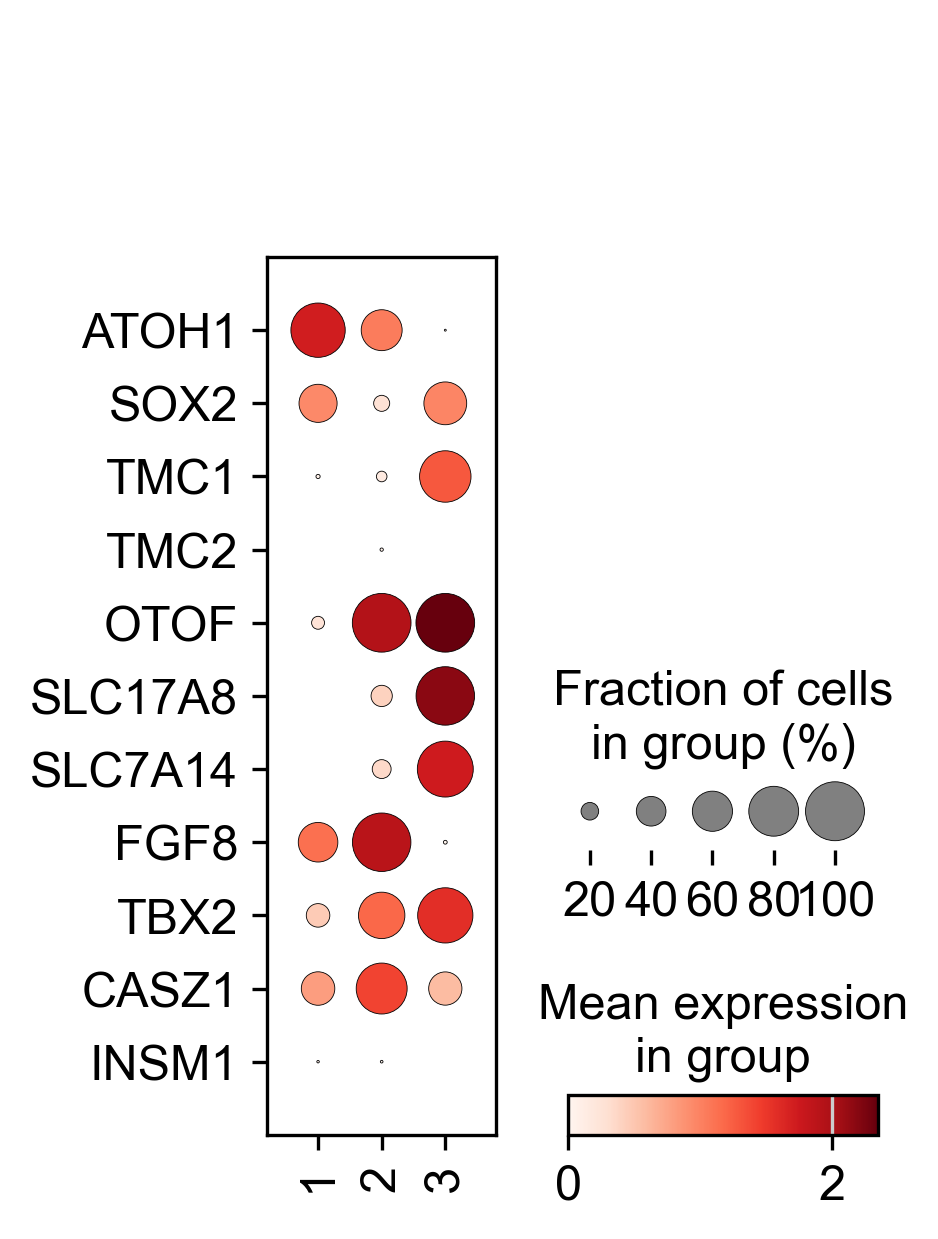

In [44]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(adata_mouse_IHC, var_names=genes, groupby='devtime', swap_axes=True,
             save="_mouse_developmental_inner_hc2.pdf",)#standard_scale='var'

In [45]:
adata_mouse_OHC=adata_mouse[adata_mouse.obs['subtype'].isin([ 'E16iHC','E14iHC','P1OHC','P7OHC','P14OHC','P28OHC' ])]
adata_mouse_OHC.obs['subtype'].value_counts()
adata_mouse_OHC.obs['timepoint'].value_counts()
adata_mouse_OHC_E14=adata_mouse_OHC[adata_mouse_OHC.obs['hc_type'].isin([ 'E14HC_proHC', ])]
adata_mouse_OHC_E14.obs['hc_type'].value_counts()
adata_mouse_OHC_E14.obs['timepoint'].value_counts()
adata_mouse_OHC_E14.obs['devtime']='1'
adata_mouse_OHC_E16=adata_mouse_OHC[adata_mouse_OHC.obs['hc_type'].isin([ 'E16HC_iOHC', ])]
adata_mouse_OHC_E16.obs['hc_type'].value_counts()
adata_mouse_OHC_E16.obs['timepoint'].value_counts()
adata_mouse_OHC_E16.obs['devtime']='1'
adata_mouse_OHC_P1=adata_mouse_OHC[adata_mouse_OHC.obs['hc_type'].isin([ 'P1HC_iOHC', ])]
adata_mouse_OHC_P1.obs['hc_type'].value_counts()
adata_mouse_OHC_P1.obs['timepoint'].value_counts()
adata_mouse_OHC_P1.obs['devtime']='2'
adata_mouse_OHC_P7=adata_mouse_OHC[adata_mouse_OHC.obs['hc_type'].isin([ 'P7HC_iOHC', ])]
adata_mouse_OHC_P7.obs['hc_type'].value_counts()
adata_mouse_OHC_P7.obs['timepoint'].value_counts()
adata_mouse_OHC_P7.obs['devtime']='2'
adata_mouse_OHC_P14=adata_mouse_OHC[adata_mouse_OHC.obs['hc_type'].isin([ 'P14HC_OHC', ])]
adata_mouse_OHC_P14.obs['hc_type'].value_counts()
adata_mouse_OHC_P14.obs['timepoint'].value_counts()
adata_mouse_OHC_P14.obs['devtime']='3'
adata_mouse_OHC_P28=adata_mouse_OHC[adata_mouse_OHC.obs['hc_type'].isin([ 'P28HC_OHC', ])]
adata_mouse_OHC_P28.obs['hc_type'].value_counts()
adata_mouse_OHC_P28.obs['timepoint'].value_counts()
adata_mouse_OHC_P28.obs['devtime']='3'

subtype
P28OHC    783
P1OHC     666
E16iHC    583
P14OHC    261
P7OHC     129
E14iHC     58
Name: count, dtype: int64

timepoint
P28HC    783
P1HC     666
E16HC    583
P14HC    261
P7HC     129
E14HC     58
Name: count, dtype: int64

hc_type
E14HC_proHC    58
Name: count, dtype: int64

timepoint
E14HC    58
Name: count, dtype: int64

hc_type
E16HC_iOHC    170
Name: count, dtype: int64

timepoint
E16HC    170
Name: count, dtype: int64

hc_type
P1HC_iOHC    217
Name: count, dtype: int64

timepoint
P1HC    217
Name: count, dtype: int64

hc_type
P7HC_iOHC    111
Name: count, dtype: int64

timepoint
P7HC    111
Name: count, dtype: int64

hc_type
P14HC_OHC    261
Name: count, dtype: int64

timepoint
P14HC    261
Name: count, dtype: int64

hc_type
P28HC_OHC    780
Name: count, dtype: int64

timepoint
P28HC    780
Name: count, dtype: int64

In [46]:
adata_mouse_OHC=adata_mouse_OHC_P28.concatenate(adata_mouse_OHC_P14,adata_mouse_OHC_P7,adata_mouse_OHC_P1,adata_mouse_OHC_E16,
                                                adata_mouse_OHC_E14
                                               )

In [47]:
sc.pp.normalize_total(adata_mouse_OHC, target_sum=1e4)
sc.pp.log1p(adata_mouse_OHC)

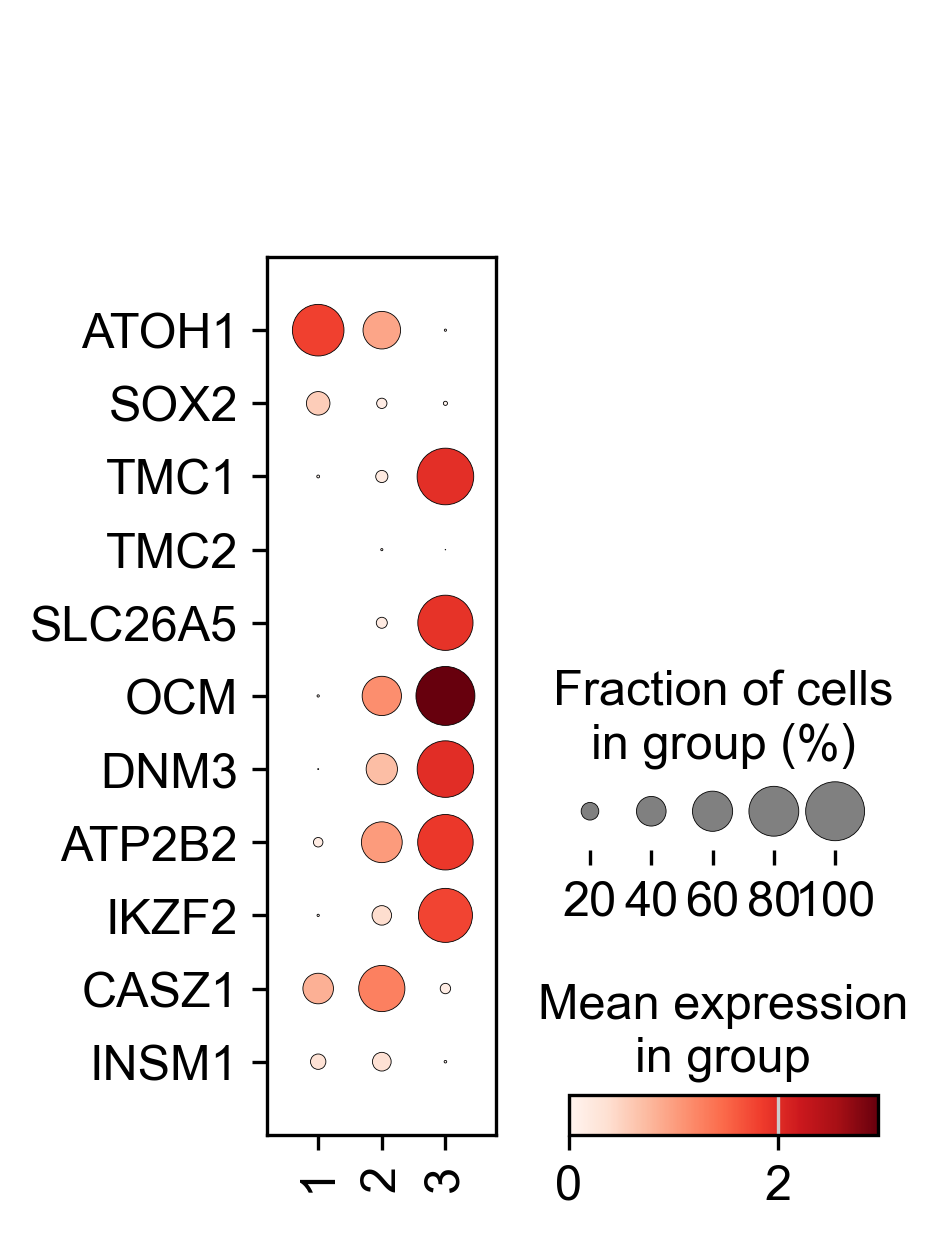

In [48]:
# Convert to categorical and specify the order if necessary
age_bins_order = sorted(adata_mouse_OHC.obs['devtime'].unique())
adata_mouse_OHC.obs['devtime'] = pd.Categorical(adata_mouse_OHC.obs['devtime'], categories=age_bins_order, ordered=True)

# Ensure 'age_bins2' is categorical
adata_mouse_OHC.obs['devtime'] = adata_mouse_OHC.obs['devtime'].astype('category')
genes2 = ['ATOH1', 'SOX2', 
         'TMC1','TMC2',
          'SLC26A5','OCM','DNM3','ATP2B2',
         'IKZF2', 'CASZ1','INSM1']
sc.pl.dotplot(adata_mouse_OHC, var_names=genes2, groupby='devtime',swap_axes=True,
             save="_mouse_developmental_outer_hc2.pdf",)#standard_scale='var'

In [78]:
# now we used our in-house mouse dataset in P21 to test whether sox2 expression in public p28 ihc is due to scrna/snrna sequencing or cell dissociation
adata_mouse=sc.read('mouse_p25_scvi.h5ad')

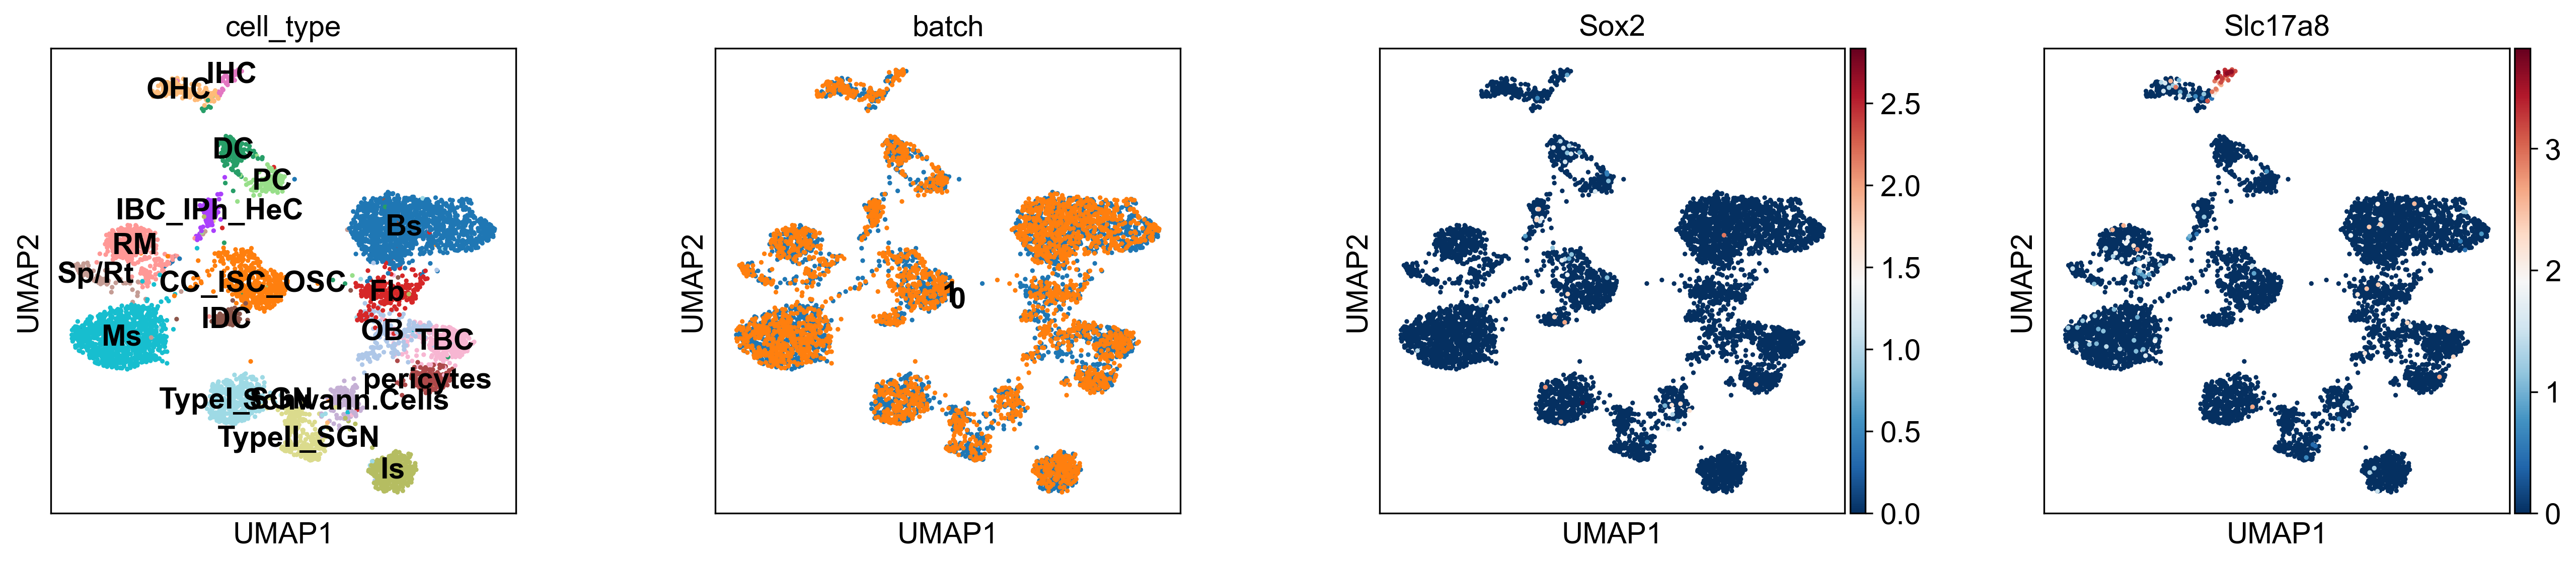

In [79]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(
    adata_mouse,
    color=['cell_type','batch','Sox2','Slc17a8',], legend_loc='on data',wspace=0.3,
    frameon=True,#
    save="cochlea-cell_type_mouse_p21_sox2.pdf"
)#ncols = 1,

In [80]:
include_clusters = ['IHC','OHC',]
adata_hc_p21= adata_mouse[adata_mouse.obs['cell_type'].isin(include_clusters), :]
adata_hc_p21

View of AnnData object with n_obs × n_vars = 225 × 32285
    obs: 'CellID', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cluster', 'cluster2', 'cell_type2', 'cell_type3', 'cell_type', 'cluster5'
    var: 'gene_ids', 'feature_types', 'Gene', 'mt', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1'
    uns: 'batch_colors', 'cell_type2_colors', 'cluster2_colors', 'leiden', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    obsp: 'connectivities', 'distances'

In [87]:
include_clusters = ['E14HC','E16HC','P1HC','P7HC','P14HC',]
adata_hc_p21_neg= adata_mouse[adata_mouse.obs['timepoint'].isin(include_clusters), :]
adata_hc_p21
adata_mouse
adata_hc_p21_neg

View of AnnData object with n_obs × n_vars = 225 × 32285
    obs: 'CellID', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cluster', 'cluster2', 'cell_type2', 'cell_type3', 'cell_type', 'cluster5'
    var: 'gene_ids', 'feature_types', 'Gene', 'mt', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1'
    uns: 'batch_colors', 'cell_type2_colors', 'cluster2_colors', 'leiden', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    obsp: 'connectivities', 'distances'

AnnData object with n_obs × n_vars = 2915 × 16823
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.hb', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'SCT_snn_res.1.1', 'SCT_snn_res.1.2', 'SCT_snn_res.1.3', 'SCT_snn_res.1.4', 'SCT_snn_res.1.5', 'SCT_snn_res.1.6', 'seurat_clusters', 'timepoint', 'subtype', 'RNA_snn_res.0.5', 'hctype', 'hc_type', 'RNA_snn_res.0.8'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

View of AnnData object with n_obs × n_vars = 1972 × 16823
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.hb', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'SCT_snn_res.1.1', 'SCT_snn_res.1.2', 'SCT_snn_res.1.3', 'SCT_snn_res.1.4', 'SCT_snn_res.1.5', 'SCT_snn_res.1.6', 'seurat_clusters', 'timepoint', 'subtype', 'RNA_snn_res.0.5', 'hctype', 'hc_type', 'RNA_snn_res.0.8'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

In [88]:
adata_hc_p21.obs['timepoint']='P21HC'

In [89]:
cluster_annotation = {
 
    'OHC': 'P21HC_OHC',
     'IHC': 'P21IHC_IHC',

}
adata_hc_p21.obs['hc_type'] = adata_hc_p21.obs['cell_type'].map(cluster_annotation).astype('category')

In [90]:
cluster_annotation = {
 
    'OHC': 'P21OHC',
     'IHC': 'P21IHC',

}
adata_hc_p21.obs['subtype'] = adata_hc_p21.obs['cell_type'].map(cluster_annotation).astype('category')

In [93]:
# mouse gene id transfer into human gene id
from mousipy import translate
adata_hc_p21 = translate(adata_hc_p21)

100%|██████████| 32285/32285 [01:23<00:00, 386.73it/s]


Found direct orthologs for 16841 genes.
Found multiple orthologs for 775 genes.
Found no orthologs for 12370 genes.
Found no index in biomart for 2299 genes.


100%|██████████| 775/775 [00:07<00:00, 108.04it/s]
                                                  

In [94]:
adata_mouse_NEW=adata_hc_p21_neg.concatenate(adata_hc_p21
                                    )
adata_mouse_NEW

AnnData object with n_obs × n_vars = 2197 × 16205
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.hb', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'SCT_snn_res.1.1', 'SCT_snn_res.1.2', 'SCT_snn_res.1.3', 'SCT_snn_res.1.4', 'SCT_snn_res.1.5', 'SCT_snn_res.1.6', 'seurat_clusters', 'timepoint', 'subtype', 'RNA_snn_res.0.5', 'hctype', 'hc_type', 'RNA_snn_res.0.8', 'CellID', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cluster', 'cluster2', 'cell_type2', 'cell_type3', 'cell_type', 'cluster5'
    var: 'vst.mean-0', 'vst.variance-0', 'vst.variance.expected-0', 'vst.variance.standardized-0', 'vst.variable-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'mt-1', 'n_cells_by_counts-0-1', 'mean_counts-0-1', 'pct_dropout_by_counts-0-1', 'total

In [95]:
adata_mouse_IHC=adata_mouse_NEW[adata_mouse_NEW.obs['subtype'].isin([ 'E16iHC','E14iHC','P1IHC','P7IHC','P14IHC','P21IHC', ])]
adata_mouse_IHC.obs['subtype'].value_counts()
adata_mouse_IHC.obs['timepoint'].value_counts()

subtype
E16iHC    583
P1IHC     181
P7IHC      61
P21IHC     60
E14iHC     58
P14IHC     33
Name: count, dtype: int64

timepoint
E16HC    583
P1HC     181
P7HC      61
P21HC     60
E14HC     58
P14HC     33
Name: count, dtype: int64

In [96]:
adata_mouse_IHC_E14=adata_mouse_IHC[adata_mouse_IHC.obs['hc_type'].isin([ 'E14HC_proHC', ])]
adata_mouse_IHC_E14.obs['hc_type'].value_counts()
adata_mouse_IHC_E14.obs['timepoint'].value_counts()
adata_mouse_IHC_E14.obs['devtime']='1'
adata_mouse_IHC_E14.obs['devtime_age_bins']='Inner_HC_1'
adata_mouse_IHC_E16=adata_mouse_IHC[adata_mouse_IHC.obs['hc_type'].isin([ 'E16HC_iIHC', ])]
adata_mouse_IHC_E16.obs['hc_type'].value_counts()
adata_mouse_IHC_E16.obs['timepoint'].value_counts()
adata_mouse_IHC_E16.obs['devtime']='1'
adata_mouse_IHC_E16.obs['devtime_age_bins']='Inner_HC_1'

hc_type
E14HC_proHC    58
Name: count, dtype: int64

timepoint
E14HC    58
Name: count, dtype: int64

hc_type
E16HC_iIHC    10
Name: count, dtype: int64

timepoint
E16HC    10
Name: count, dtype: int64

In [97]:
adata_mouse_IHC_P1=adata_mouse_IHC[adata_mouse_IHC.obs['hc_type'].isin([ 'P1HC_iIHC', ])]
adata_mouse_IHC_P1.obs['hc_type'].value_counts()
adata_mouse_IHC_P1.obs['timepoint'].value_counts()
adata_mouse_IHC_P1.obs['devtime']='2'
adata_mouse_IHC_P1.obs['devtime_age_bins']='Inner_HC_2'
adata_mouse_IHC_P7=adata_mouse_IHC[adata_mouse_IHC.obs['hc_type'].isin([ 'P7HC_iIHC', ])]
adata_mouse_IHC_P7.obs['hc_type'].value_counts()
adata_mouse_IHC_P7.obs['timepoint'].value_counts()
adata_mouse_IHC_P7.obs['devtime']='2'
adata_mouse_IHC_P7.obs['devtime_age_bins']='Inner_HC_2'

hc_type
P1HC_iIHC    126
Name: count, dtype: int64

timepoint
P1HC    126
Name: count, dtype: int64

hc_type
P7HC_iIHC    61
Name: count, dtype: int64

timepoint
P7HC    61
Name: count, dtype: int64

In [98]:
adata_mouse_IHC_P14=adata_mouse_IHC[adata_mouse_IHC.obs['hc_type'].isin([ 'P14HC_IHC', ])]
adata_mouse_IHC_P14.obs['hc_type'].value_counts()
adata_mouse_IHC_P14.obs['timepoint'].value_counts()
adata_mouse_IHC_P14.obs['devtime']='3'
adata_mouse_IHC_P14.obs['devtime_age_bins']='Inner_HC_3'
adata_mouse_IHC_P21=adata_mouse_IHC[adata_mouse_IHC.obs['hc_type'].isin([ 'P21IHC_IHC', ])]
adata_mouse_IHC_P21.obs['hc_type'].value_counts()
adata_mouse_IHC_P21.obs['timepoint'].value_counts()
adata_mouse_IHC_P21.obs['devtime']='3'
adata_mouse_IHC_P21.obs['devtime_age_bins']='Inner_HC_3'

hc_type
P14HC_IHC    33
Name: count, dtype: int64

timepoint
P14HC    33
Name: count, dtype: int64

hc_type
P21IHC_IHC    60
Name: count, dtype: int64

timepoint
P21HC    60
Name: count, dtype: int64

In [99]:
adata_mouse_IHC=adata_mouse_IHC_P21.concatenate(adata_mouse_IHC_P14,adata_mouse_IHC_P7,adata_mouse_IHC_P1,adata_mouse_IHC_E16,
                                                adata_mouse_IHC_E14
                                               )

In [100]:
sc.pp.normalize_total(adata_mouse_IHC, target_sum=1e4)
sc.pp.log1p(adata_mouse_IHC)

normalizing counts per cell
    finished (0:00:00)


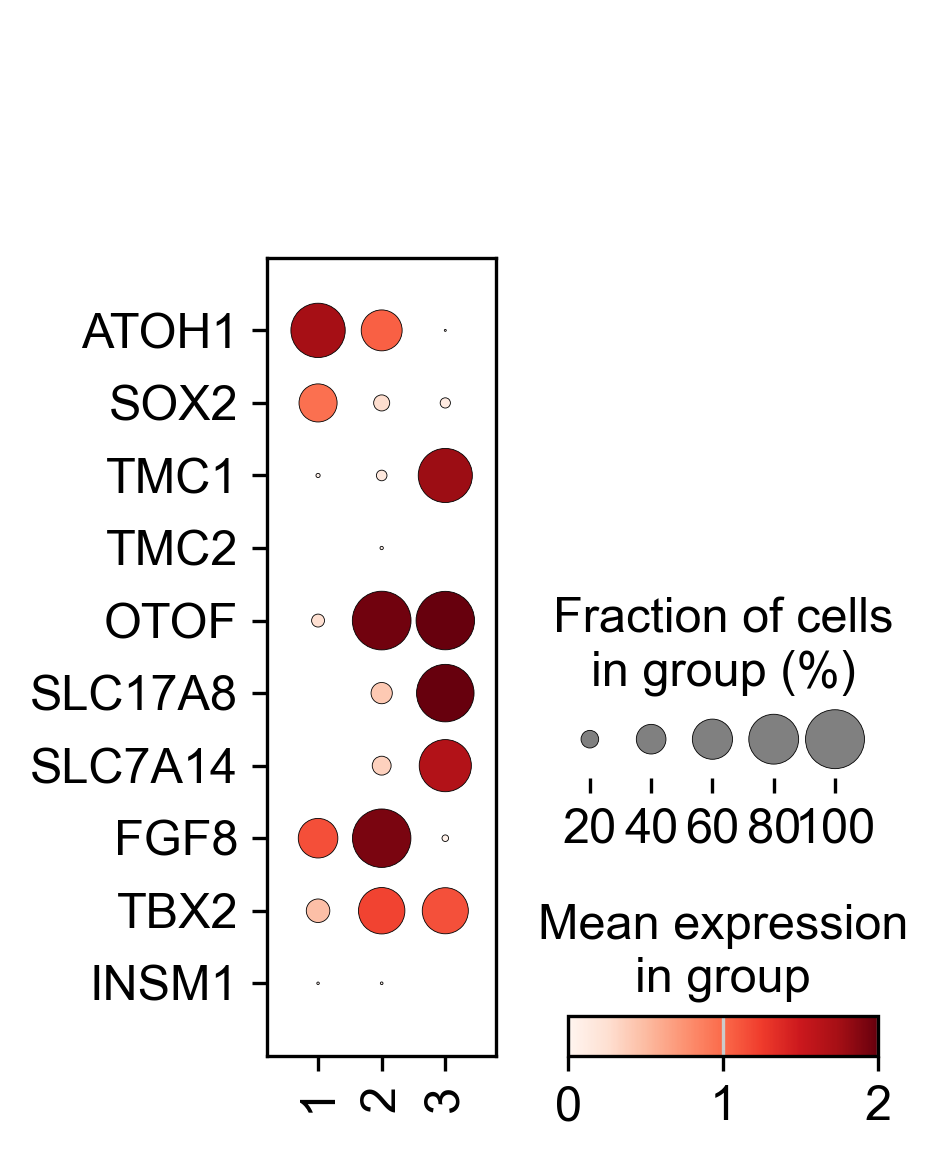

In [101]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
age_bins_order = sorted(adata_mouse_IHC.obs['devtime'].unique())
adata_mouse_IHC.obs['devtime'] = pd.Categorical(adata_mouse_IHC.obs['devtime'], categories=age_bins_order, ordered=True)

# Ensure 'age_bins2' is categorical
adata_mouse_IHC.obs['devtime'] = adata_mouse_IHC.obs['devtime'].astype('category')

# List of genes to plot
genes = ['ATOH1', 'SOX2', 
         'TMC1','TMC2',
          'OTOF','SLC17A8','SLC7A14','FGF8',
         'TBX2', 'INSM1']#'CASZ1', UNDETECTED IN P21 IHC
sc.pl.dotplot(adata_mouse_IHC, var_names=genes, groupby='devtime', swap_axes=True,
             save="_mouse_developmental_inner_hc2_REVISION.pdf",vmax=2)#standard_scale='var'

In [102]:
adata_mouse_OHC=adata_mouse_NEW[adata_mouse_NEW.obs['subtype'].isin([ 'E16iHC','E14iHC','P1OHC','P7OHC','P14OHC','P21OHC' ])]
adata_mouse_OHC.obs['subtype'].value_counts()
adata_mouse_OHC.obs['timepoint'].value_counts()
adata_mouse_OHC_E14=adata_mouse_OHC[adata_mouse_OHC.obs['hc_type'].isin([ 'E14HC_proHC', ])]
adata_mouse_OHC_E14.obs['hc_type'].value_counts()
adata_mouse_OHC_E14.obs['timepoint'].value_counts()
adata_mouse_OHC_E14.obs['devtime']='1'
adata_mouse_OHC_E14.obs['devtime_age_bins']='Outer_HC_1'

adata_mouse_OHC_E16=adata_mouse_OHC[adata_mouse_OHC.obs['hc_type'].isin([ 'E16HC_iOHC', ])]
adata_mouse_OHC_E16.obs['hc_type'].value_counts()
adata_mouse_OHC_E16.obs['timepoint'].value_counts()
adata_mouse_OHC_E16.obs['devtime']='1'
adata_mouse_OHC_E16.obs['devtime_age_bins']='Outer_HC_1'

adata_mouse_OHC_P1=adata_mouse_OHC[adata_mouse_OHC.obs['hc_type'].isin([ 'P1HC_iOHC', ])]
adata_mouse_OHC_P1.obs['hc_type'].value_counts()
adata_mouse_OHC_P1.obs['timepoint'].value_counts()
adata_mouse_OHC_P1.obs['devtime']='2'
adata_mouse_OHC_P1.obs['devtime_age_bins']='Outer_HC_2'

adata_mouse_OHC_P7=adata_mouse_OHC[adata_mouse_OHC.obs['hc_type'].isin([ 'P7HC_iOHC', ])]
adata_mouse_OHC_P7.obs['hc_type'].value_counts()
adata_mouse_OHC_P7.obs['timepoint'].value_counts()
adata_mouse_OHC_P7.obs['devtime']='2'
adata_mouse_OHC_P7.obs['devtime_age_bins']='Outer_HC_2'

adata_mouse_OHC_P14=adata_mouse_OHC[adata_mouse_OHC.obs['hc_type'].isin([ 'P14HC_OHC', ])]
adata_mouse_OHC_P14.obs['hc_type'].value_counts()
adata_mouse_OHC_P14.obs['timepoint'].value_counts()
adata_mouse_OHC_P14.obs['devtime']='3'
adata_mouse_OHC_P14.obs['devtime_age_bins']='Outer_HC_3'

adata_mouse_OHC_P21=adata_mouse_OHC[adata_mouse_OHC.obs['hc_type'].isin([ 'P21HC_OHC', ])]
adata_mouse_OHC_P21.obs['hc_type'].value_counts()
adata_mouse_OHC_P21.obs['timepoint'].value_counts()
adata_mouse_OHC_P21.obs['devtime']='3'
adata_mouse_OHC_P21.obs['devtime_age_bins']='Outer_HC_3'

subtype
P1OHC     666
E16iHC    583
P14OHC    261
P21OHC    165
P7OHC     129
E14iHC     58
Name: count, dtype: int64

timepoint
P1HC     666
E16HC    583
P14HC    261
P21HC    165
P7HC     129
E14HC     58
Name: count, dtype: int64

hc_type
E14HC_proHC    58
Name: count, dtype: int64

timepoint
E14HC    58
Name: count, dtype: int64

hc_type
E16HC_iOHC    170
Name: count, dtype: int64

timepoint
E16HC    170
Name: count, dtype: int64

hc_type
P1HC_iOHC    217
Name: count, dtype: int64

timepoint
P1HC    217
Name: count, dtype: int64

hc_type
P7HC_iOHC    111
Name: count, dtype: int64

timepoint
P7HC    111
Name: count, dtype: int64

hc_type
P14HC_OHC    261
Name: count, dtype: int64

timepoint
P14HC    261
Name: count, dtype: int64

hc_type
P21HC_OHC    165
Name: count, dtype: int64

timepoint
P21HC    165
Name: count, dtype: int64

In [103]:
adata_mouse_OHC=adata_mouse_OHC_P21.concatenate(adata_mouse_OHC_P14,adata_mouse_OHC_P7,adata_mouse_OHC_P1,adata_mouse_OHC_E16,
                                                adata_mouse_OHC_E14
                                               )

In [104]:
sc.pp.normalize_total(adata_mouse_OHC, target_sum=1e4)
sc.pp.log1p(adata_mouse_OHC)

normalizing counts per cell
    finished (0:00:00)


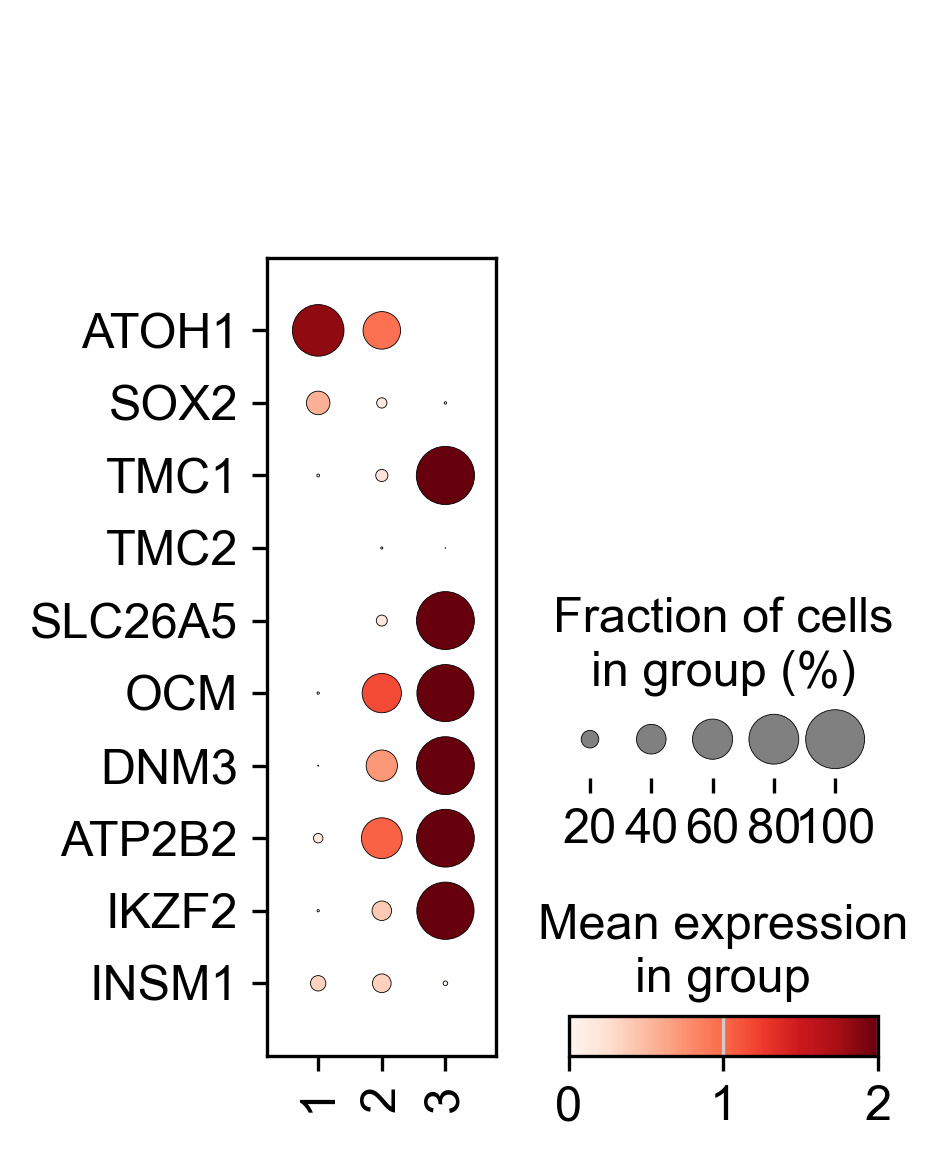

In [105]:
# Convert to categorical and specify the order if necessary
age_bins_order = sorted(adata_mouse_OHC.obs['devtime'].unique())
adata_mouse_OHC.obs['devtime'] = pd.Categorical(adata_mouse_OHC.obs['devtime'], categories=age_bins_order, ordered=True)

# Ensure 'age_bins2' is categorical
adata_mouse_OHC.obs['devtime'] = adata_mouse_OHC.obs['devtime'].astype('category')
genes2 = ['ATOH1', 'SOX2', 
         'TMC1','TMC2',
          'SLC26A5','OCM','DNM3','ATP2B2',
         'IKZF2', 'INSM1']#'CASZ1',
sc.pl.dotplot(adata_mouse_OHC, var_names=genes2, groupby='devtime',swap_axes=True,
             save="_mouse_developmental_outer_hc2_REVISION.pdf",vmax=2)#standard_scale='var'

### FIGURE S4e

In [49]:
adata_mouse_OHC.obs['age_bins2']=adata_mouse_OHC.obs['devtime']
adata_mouse_OHC.obs['age_bins2'].value_counts()
adata_mouse_OHC.obs['devtime'].value_counts()

age_bins2
3    1041
2     328
1     228
Name: count, dtype: int64

devtime
3    1041
2     328
1     228
Name: count, dtype: int64

In [50]:
adata_mouse_IHC.obs['age_bins2']=adata_mouse_IHC.obs['devtime']
adata_mouse_IHC.obs['age_bins2'].value_counts()
adata_mouse_IHC.obs['devtime'].value_counts()

age_bins2
3    193
2    187
1     68
Name: count, dtype: int64

devtime
3    193
2    187
1     68
Name: count, dtype: int64

In [51]:
adata_mouse_v2=adata_mouse_OHC.concatenate(adata_mouse_IHC)
adata_mouse_v2
adata_mouse_v2.obs['age_bins2']=adata_mouse_v2.obs['devtime']
adata_mouse_v2.obs['age_bins2'].value_counts()
adata_mouse_v2.obs['devtime'].value_counts()
adata_mouse_v2_OHC=adata_mouse_v2[adata_mouse_v2.obs['hc_type'].isin([ 'P28HC_OHC','P14HC_OHC','P1HC_iOHC','E14HC_proHC','P7HC_iOHC','E16HC_iOHC' ])]
adata_mouse_v2_OHC.obs['hc_type'].value_counts()
adata_mouse_v2_OHC.obs['timepoint'].value_counts()
adata_mouse_v2_OHC.obs['age_bins2'].value_counts()
adata_mouse_v2_IHC=adata_mouse_v2[adata_mouse_v2.obs['hc_type'].isin([ 'P28HC_IHC','P1HC_iIHC','E14HC_proHC','P7HC_iIHC','P14HC_IHC','E16HC_iIHC' ])]
adata_mouse_v2_IHC.obs['hc_type'].value_counts()
adata_mouse_v2_IHC.obs['timepoint'].value_counts()
adata_mouse_v2_IHC.obs['age_bins2'].value_counts()

AnnData object with n_obs × n_vars = 2045 × 16823
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.hb', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'SCT_snn_res.1.1', 'SCT_snn_res.1.2', 'SCT_snn_res.1.3', 'SCT_snn_res.1.4', 'SCT_snn_res.1.5', 'SCT_snn_res.1.6', 'seurat_clusters', 'timepoint', 'subtype', 'RNA_snn_res.0.5', 'hctype', 'hc_type', 'RNA_snn_res.0.8', 'devtime', 'batch', 'age_bins2'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

age_bins2
3    1234
2     515
1     296
Name: count, dtype: int64

devtime
3    1234
2     515
1     296
Name: count, dtype: int64

hc_type
P28HC_OHC      780
P14HC_OHC      261
P1HC_iOHC      217
E16HC_iOHC     170
E14HC_proHC    116
P7HC_iOHC      111
Name: count, dtype: int64

timepoint
P28HC    780
P14HC    261
P1HC     217
E16HC    170
E14HC    116
P7HC     111
Name: count, dtype: int64

age_bins2
3    1041
2     328
1     286
Name: count, dtype: int64

hc_type
P28HC_IHC      160
P1HC_iIHC      126
E14HC_proHC    116
P7HC_iIHC       61
P14HC_IHC       33
E16HC_iIHC      10
Name: count, dtype: int64

timepoint
P28HC    160
P1HC     126
E14HC    116
P7HC      61
P14HC     33
E16HC     10
Name: count, dtype: int64

age_bins2
3    193
2    187
1    126
Name: count, dtype: int64

In [ ]:
#export human and mouse inner or outer hair cells for Jaccard index-based transcriptional similarity analysis

adata_human_OHC.write_loom(data_dir + 'adata_human_OHC.loom')
adata_human_OHC.obs.to_csv(data_dir +'adata_human_OHC_obs.csv')
adata_human_OHC.var.to_csv(data_dir +'adata_human_OHC_var.csv')
adata_human_IHC.write_loom(data_dir + 'adata_human_IHC.loom')
adata_human_IHC.obs.to_csv(data_dir +'adata_human_IHC_obs.csv')
adata_human_IHC.var.to_csv(data_dir +'adata_human_IHC_var.csv')

In [ ]:
#export human and mouse inner or outer hair cells for Jaccard index-based transcriptional similarity analysis

adata_mouse_v2_OHC.write_loom(data_dir + 'adata_mouse_v2_OHC.loom')
adata_mouse_v2_OHC.obs.to_csv(data_dir +'adata_mouse_v2_OHC_obs.csv')
adata_mouse_v2_OHC.var.to_csv(data_dir +'adata_mouse_v2_OHC_var.csv')
adata_mouse_v2_IHC.write_loom(data_dir + 'adata_mouse_v2_IHC.loom')
adata_mouse_v2_IHC.obs.to_csv(data_dir +'adata_mouse_v2_IHC_obs.csv')
adata_mouse_v2_IHC.var.to_csv(data_dir +'adata_mouse_v2_IHC_var.csv')

### FIGURE S4f

In [52]:
#MECHINE LEARNING svm MODEL FOR ACCESSING THE PROPABILITY OF human CELL TYPE TRANSFER TO MANUALT ANNOTATED MOUSE CELL TYPE
import os 
import sys
import datetime
import numpy
import pandas
import scanpy 
import anndata
import scipy 
import matplotlib.pyplot
import functools
import random
import itertools
import warnings
import argparse
import seaborn

In [53]:
# Required libraries regardless of the model you choose

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [54]:
# Library for Logistic Regression
from sklearn.linear_model import LogisticRegression

# Library for Random Forest 
from sklearn.ensemble import RandomForestClassifier

# Library for Support Vector Machine 
from sklearn.svm import SVC

#Suppress lots of memory warning
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
from os.path import expanduser as eu
from os import path

scanpy.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from itertools import chain

In [55]:
def preprocessing_training(adata, hvgs):
    # Per cell normalization
    sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
    # Log transformation 
    sc.pp.log1p(adata)
    # Filter HVGs --> Select top N highly variable genes that will serve as features to the machine learning models  
    sc.pp.highly_variable_genes(adata, n_top_genes = hvgs)
    highly_variable_genes = adata.var["highly_variable"]
    adata = adata[:, highly_variable_genes]
    # Scale
    sc.pp.scale(adata, max_value=10)
    return adata

def preprocessing_testing(adata, hvgs): 
    # Per cell normalization
    sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
    # Log transformation 
    sc.pp.log1p(adata)
    # Use the HVGs that were selected for the training set 
    adata = adata[:, hvgs]
    # Scale
    sc.pp.scale(adata, max_value=10)
    return adata

In [58]:
adata_mouse_v2_OHC.obs['species']='mouse'
adata_human_OHC.obs['species']='human'

In [59]:
adata = anndata.concat([adata_mouse_v2_OHC, adata_human_OHC]) #change to IHCs
adata

AnnData object with n_obs × n_vars = 1749 × 16139
    obs: 'nCount_RNA', 'nFeature_RNA', 'batch', 'age_bins2', 'species'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

In [60]:
adata_human2= adata[adata.obs['species'].isin(['human']), :]
adata_human2
adata_mouse2= adata[adata.obs['species'].isin(['mouse']), :]
adata_mouse2

View of AnnData object with n_obs × n_vars = 94 × 16139
    obs: 'nCount_RNA', 'nFeature_RNA', 'batch', 'age_bins2', 'species'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

View of AnnData object with n_obs × n_vars = 1655 × 16139
    obs: 'nCount_RNA', 'nFeature_RNA', 'batch', 'age_bins2', 'species'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

In [61]:
X_df = pd.DataFrame(adata_mouse2.X.toarray(), index = adata_mouse2.obs_names, columns = adata_mouse2.var_names) 
# Fetching the count matrix to use as input to the model 
print(type(X_df), X_df.shape)

<class 'pandas.core.frame.DataFrame'> (1655, 16139)


In [62]:
# Labels we want to predict 
y = list(adata_mouse2.obs['age_bins2'].astype('str'))
print('List of unique labels we wish to transfer: {}'.format(numpy.unique(y)))

List of unique labels we wish to transfer: ['1' '2' '3']


In [63]:
# Split the training dataset into train and test sets 
X_train, X_test, y_train, y_test = train_test_split(
        X_df,
        y,
        test_size=0.3, # This can be changed, though it makes sense to use 25-30% of the data for test
        random_state=1234,
    )

X_train_indices = X_train.index.to_list()
X_test_indices = X_test.index.to_list()
X_train = preprocessing_training(adata_mouse2[X_train_indices, :], 1500)#n_hvgs 1000

hvgs_X_train = X_train.var_names.to_list()
X_test = preprocessing_testing(adata_mouse2[X_test_indices, :], hvgs_X_train)

X_train = X_train.X
X_test = X_test.X

normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added
    'n_counts', counts per cell before normalization (adata.obs)
extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added
    'n_counts', counts per cell before normalization (adata.obs)


In [64]:
# Train supervised learning models #
# Compute smoothing class weights 
def class_weight(labels_dict,mu=0.15):
    total = numpy.sum(list(labels_dict.values()))
    keys = labels_dict.keys()
    weight = {}
    print(total)

    for i in keys:
        score = numpy.log(mu*total/float(labels_dict[i]))
        weight[i] = score if score > 1 else 1
    return weight

labels_dict = {}
for i in y_train:
    labels_dict[i] = labels_dict.get(i, 0) + 1

print(labels_dict)
weights = class_weight(labels_dict)

{'2': 224, '3': 726, '1': 208}
1158


In [65]:
#Training a Support Vector Machine multiclass classifier
svm = SVC(kernel = "rbf", probability = True, class_weight = weights)

In [66]:
pca = PCA()
pca

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [67]:
pipe = Pipeline(steps=[('pca', pca), ('SVC', svm)])
print('Starting hyperparameter tuning with exhaustive grid search')

Starting hyperparameter tuning with exhaustive grid search


In [68]:
# Choose a grid of hyperparameters values (these are arbitrary but reasonable as I took reference values from the documentation)
params_svm = {'SVC__C':[0.1, 1, 10, 100], 'SVC__gamma':[0.001, 0.01, 0.1], 'pca__n_components': [0.7, 0.8, 0.9]}

In [69]:
# Use grid search cross validation to span the hyperparameter space and choose the best 
grid = GridSearchCV(pipe, param_grid = params_svm, cv=5, verbose =1, n_jobs = -1)
grid

,estimator,Pipeline(step...ility=True))])
,param_grid,"{'SVC__C': [0.1, 1, ...], 'SVC__gamma': [0.001, 0.01, ...], 'pca__n_components': [0.7, 0.8, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,None


In [70]:
# Fit the model to the training set of the training data
grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,Pipeline(step...ility=True))])
,param_grid,"{'SVC__C': [0.1, 1, ...], 'SVC__gamma': [0.001, 0.01, ...], 'pca__n_components': [0.7, 0.8, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,0.9


In [71]:
# Evaluate supervised learning models #
predicted_labels = grid.best_estimator_.predict(X_test) 
report = classification_report(y_test, predicted_labels)
print("Accuracy:", accuracy_score(y_test, predicted_labels))
print(report)

Accuracy: 0.9054325955734407
              precision    recall  f1-score   support

           1       1.00      0.40      0.57        78
           2       0.69      1.00      0.82       104
           3       1.00      1.00      1.00       315

    accuracy                           0.91       497
   macro avg       0.90      0.80      0.79       497
weighted avg       0.93      0.91      0.89       497



([<matplotlib.axis.XTick at 0x2531e4a2650>,
 [Text(0, 0, '0'), Text(1, 0, '1')])

([<matplotlib.axis.YTick at 0x2531e4a1090>,
 [Text(0, 0, '0'), Text(0, 1, '1')])

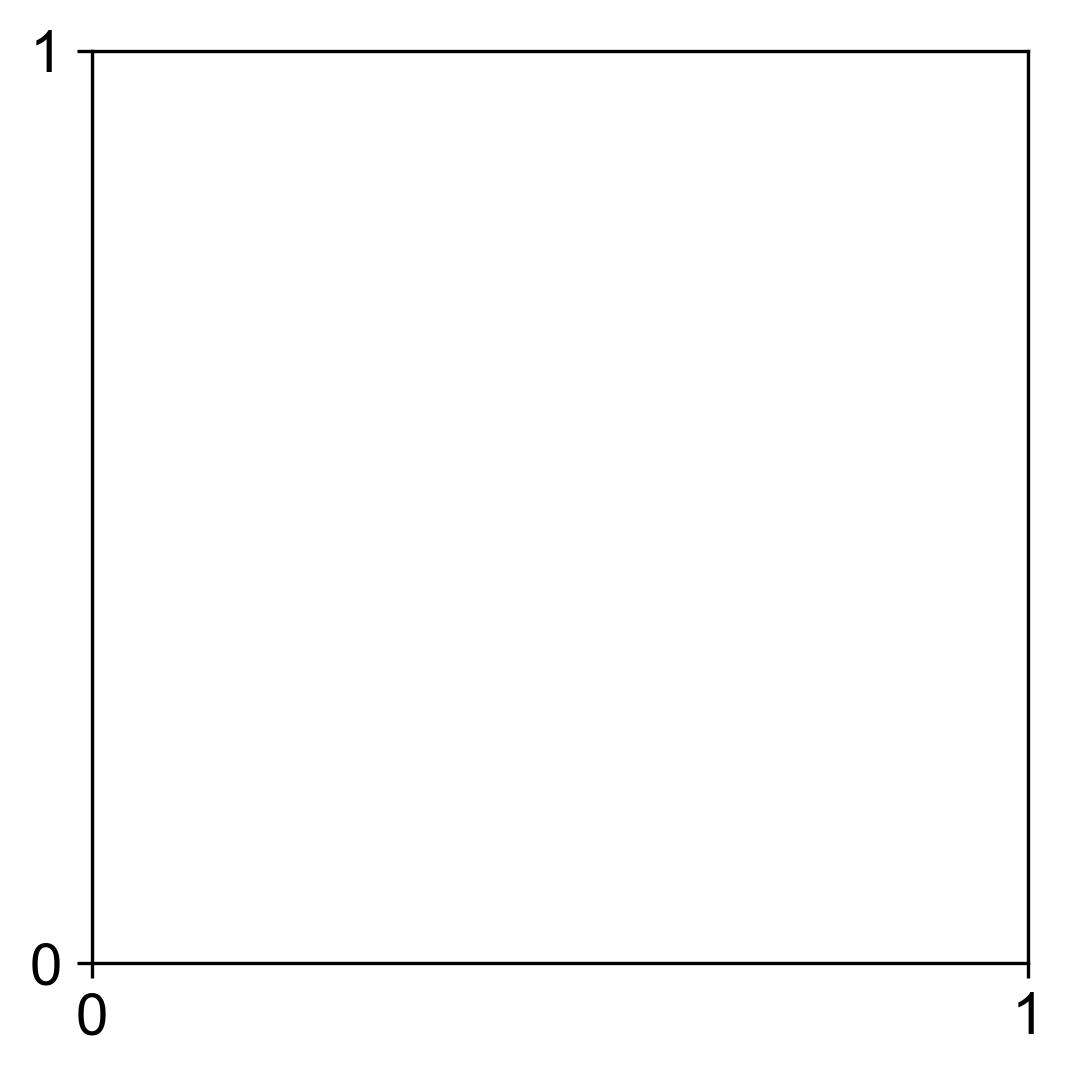

In [72]:
# Confusion matrix 
cnf_matrix = confusion_matrix(y_test, predicted_labels)

class_names=[0,1] # name  of classes
fig, ax = matplotlib.pyplot.subplots()
tick_marks = numpy.arange(len(class_names))
matplotlib.pyplot.xticks(tick_marks, class_names)
matplotlib.pyplot.yticks(tick_marks, class_names)

<Axes: >

Text(0.5, 1.1, 'Confusion matrix')

Text(57.083333333333336, 0.5, 'Actual label')

Text(0.5, 39.08333333333335, 'Predicted label')

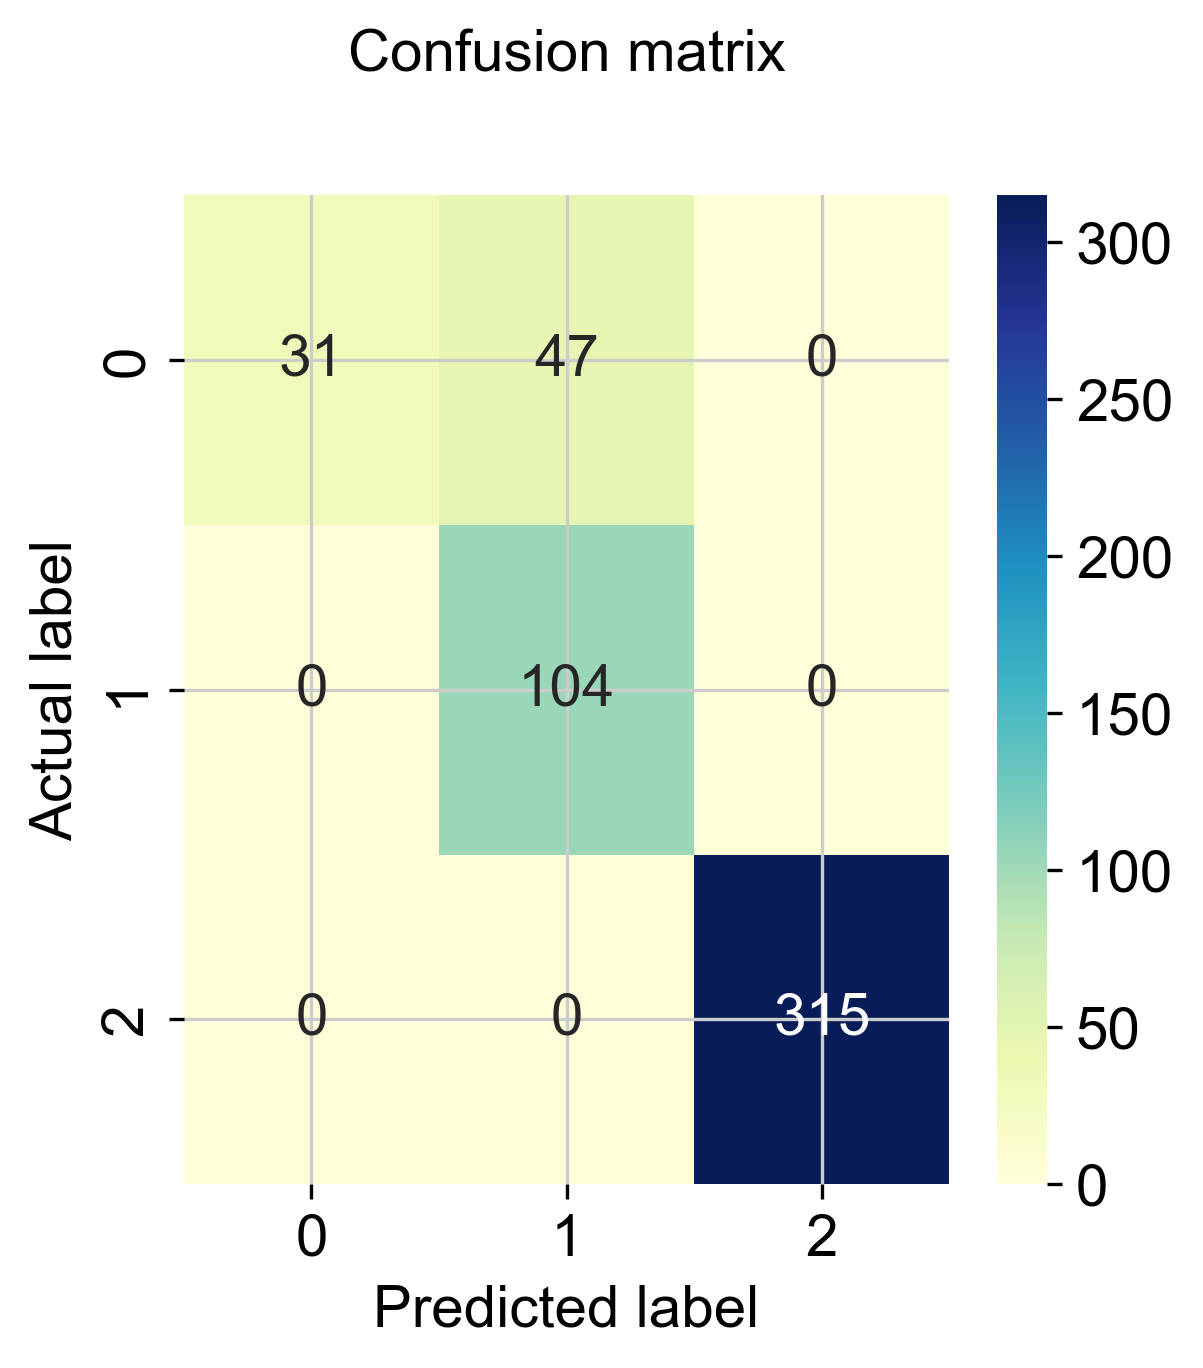

In [73]:
# create heatmap
seaborn.heatmap(pandas.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.title('Confusion matrix', y=1.1)
matplotlib.pyplot.ylabel('Actual label')
matplotlib.pyplot.xlabel('Predicted label')

In [74]:
# Transfer labels #
###################

grid.best_estimator_.feature_names = hvgs_X_train

def process_and_subset_data(adata, genes):
    # save the log transformed counts as raw 
    adata.raw = adata.copy()
    # Per cell normalization
    sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
    # Log transformation 
    sc.pp.log1p(adata)
    # Subset data
    adata = adata[:, list(genes)]
    # Scale
    sc.pp.scale(adata, max_value=10)
    return adata

def make_single_predictions(adata, classifier): 
    #if scipy.sparse.issparse(adata.X):
        #adata.X = adata.X.toarray()
    adata_X = numpy.array(adata.X)
    print(type(adata_X), adata_X.shape)
    adata_preds = classifier.predict(adata_X)
    adata.obs['classifier'] = adata_preds
    print(adata.obs.classifier.value_counts(dropna = False))
    
def make_correspondence(classifier):
    corr = {}
    for i in range(0,len(classifier.classes_)):
            corr[i] = classifier.classes_[i]
    return corr

def make_probability_predictions(adata, classifier):
    adata_X = numpy.array(adata.X)
    print(type(adata_X), adata_X.shape)
    proba_preds = classifier.predict_proba(adata_X)
    df_probs = pd.DataFrame(numpy.column_stack(list(zip(*proba_preds))))
    corr = make_correspondence(classifier)
    for index in df_probs.columns.values:
        celltype = corr[index]
        adata.obs['prob_'+celltype] = df_probs[index].to_list()

In [75]:
adata_human2 = process_and_subset_data(adata_human2, grid.best_estimator_.feature_names)
make_single_predictions(adata_human2, grid.best_estimator_)
make_probability_predictions(adata_human2, grid.best_estimator_)

to_save = ['classifier']
for i in adata_human2.obs.columns:
    if i.startswith('prob_'):
        to_save.append(i)

print('Saving the following obs: {}'.format(to_save))

normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added
    'n_counts', counts per cell before normalization (adata.obs)
<class 'numpy.ndarray'> (94, 1500)
classifier
3    78
2    16
Name: count, dtype: int64
<class 'numpy.ndarray'> (94, 1500)
Saving the following obs: ['classifier', 'prob_1', 'prob_2', 'prob_3']


In [76]:
# Save transferred labels #
adata_human2.obs[to_save].to_csv(data_dir+'figures/figure3_S4/transferred_labels_svm_ohc_1500hvgs.csv')#CHANGE OHC IHC,RESPECTIVELY
#this csv formated-result then is as input as box-plot visualization in graphpad.

In [77]:
# visulization with GRAPHPAD PRISM